# Data visualization

In [1]:
import pandas as pd
import plotnine as p9
df = pd.read_csv('dataset_clean_tidy_filled.csv')


**Request 1.** Create a chart showing the number of patients per disease category (dzgroup), in descending order of count.

             dzgroup  patient_count
0  arf/mosf w/sepsis           3500
1                chf           1385
2               copd            963
3        lung cancer            905
4       mosf w/malig            704
5               coma            592
6       colon cancer            508
7          cirrhosis            506


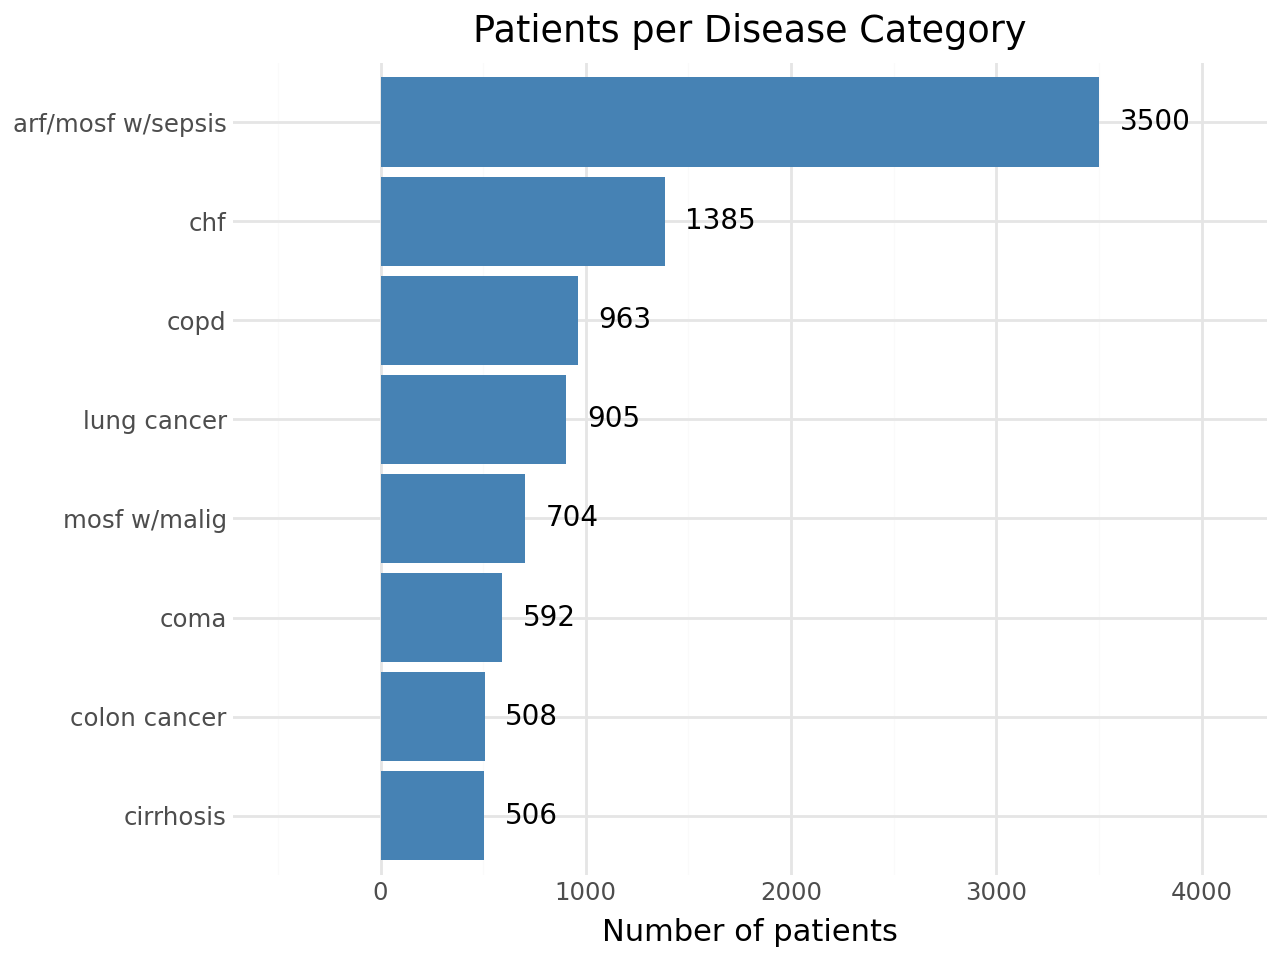

In [3]:
dzg_counts = df['dzgroup'].value_counts().reset_index()

dzg_counts.columns = ['dzgroup', 'patient_count']

ordered_rev = dzg_counts['dzgroup'].tolist()[::-1]

df_plot=df.copy()
df_plot['Outcome'] = df_plot['hospdead'].map({0: 'Survived', 1: 'Dead'})

dzg_counts['dzgroup'] = pd.Categorical(dzg_counts['dzgroup'], categories=ordered_rev, ordered=True)
df_plot['dzgroup'] = pd.Categorical(df_plot['dzgroup'], categories=ordered_rev, ordered=True)
print(dzg_counts)
(p9.ggplot(dzg_counts,p9.aes(x='dzgroup', y='patient_count'))
    + p9.geom_col(fill='steelblue')
    + p9.coord_flip()
    + p9.scale_y_continuous(expand=(0.2, 0))
    + p9.geom_text(p9.aes(label='patient_count.astype(str)'), ha='left', nudge_y=100, size=10)
    + p9.theme_minimal()
    + p9.labs(title="Patients per Disease Category", x="", y="Number of patients")
)


The chart illustrates the total number of hospital admissions categorized by the patient's primary disease group, ranked from highest to lowest volume.

Key Takeaways:

* Dominant Category: The dataset is overwhelmingly dominated by ARF/MOSF w/Sepsis, which alone accounts for 3,500 admissions.

* Middle Tier: Cardiac and respiratory conditions (CHF at 1,385 and COPD at 963) make up the next largest block of patients.

* Lowest Volume: Diagnoses such as Coma, Colon Cancer, and Cirrhosis are the least frequent primary admission causes in this cohort, each containing fewer than 600 patients.

**Request 2.** Then, create a second chart showing, for each disease category, the proportion of patients who died in hospital versus those who survived. Use appropriate titles, axis labels, and a legend. Comment on which disease groups appear most lethal.


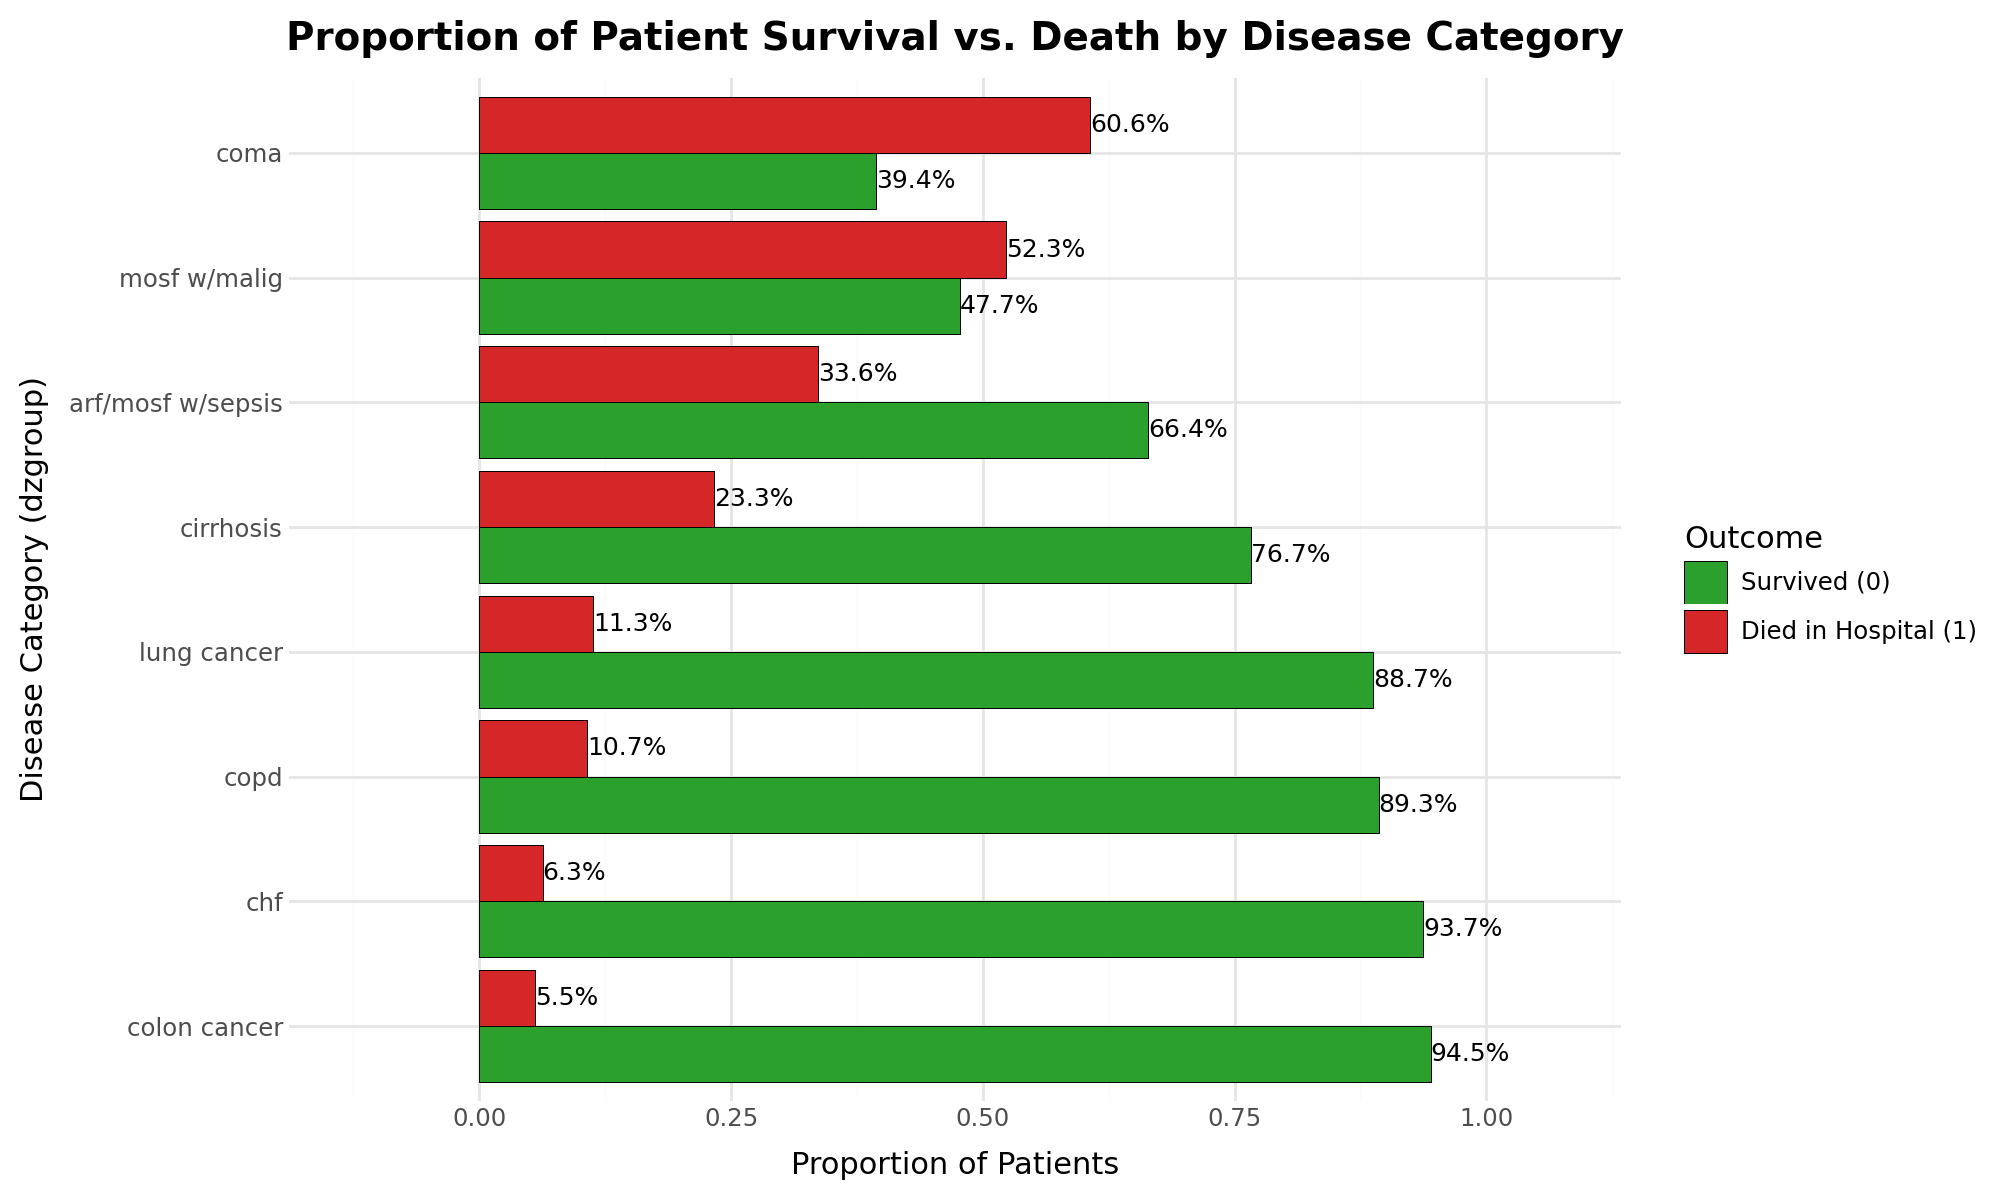

In [4]:
df_agg = df.groupby(['dzgroup', 'hospdead']).size().reset_index(name='count')

df_agg['pct'] = df_agg.groupby('dzgroup')['count'].transform(lambda x: x / x.sum())

df_agg['pct_label'] = (df_agg['pct'] * 100).round(1).astype(str) + '%'

mortality_rates = df.groupby('dzgroup')['hospdead'].mean().sort_values(ascending=True)
df_agg['dzgroup_mortality'] = pd.Categorical(df_agg['dzgroup'], categories=mortality_rates.index, ordered=True)
df_agg['outcome'] = df_agg['hospdead'].map({0: 'Survived (0)', 1: 'Died in Hospital (1)'})
df_agg['outcome'] = pd.Categorical(df_agg['outcome'], categories=['Survived (0)', 'Died in Hospital (1)'], ordered=True)


(
    p9.ggplot(df_agg, p9.aes(x='dzgroup_mortality', y='pct', fill='outcome'))
    
    + p9.geom_col(position=p9.position_dodge(width=0.9), color='black', size=0.2)
    
    + p9.geom_text(
        p9.aes(label='pct_label'),
        position=p9.position_dodge(width=0.9),
        ha='left',      
        size=9,
        color='black'
    )
    + p9.coord_flip()
    + p9.scale_fill_manual(values={'Survived (0)': '#2ca02c', 'Died in Hospital (1)': '#d62728'}) 
    + p9.labs(
        title='Proportion of Patient Survival vs. Death by Disease Category',
        x='Disease Category (dzgroup)',
        y='Proportion of Patients',
        fill='Outcome'
    )
    + p9.scale_y_continuous(expand=(0.2, 0))
    + p9.theme_minimal()
    + p9.theme(
        figure_size=(10, 6),
        plot_title=p9.element_text(size=14, weight='bold')
    )
)

This grouped bar chart normalizes the patient count within each disease category to 100%, allowing for a direct comparison of relative lethality regardless of the absolute number of admissions. The categories are sorted from highest to lowest mortality.

Key Takeaways:

* Highest Lethality: Coma (60.6% mortality) and MOSF w/Malig (52.3% mortality) are the only conditions where the probability of death exceeds or roughly equals the probability of survival.

* Moderate Lethality: ARF/MOSF w/sepsis and Cirrhosis show significant, though lower, mortality rates (33.6% and 23.3%).

* Highest Survival: CHF and Colon Cancer have the most favorable in-hospital survival ratios, both exceeding 93% survivability.


**Request 3.** Compute the in-hospital mortality rate broken down by sex and race, produce an appropriate visualization to show the results and write a short paragraph summarizing what the plot reveals.

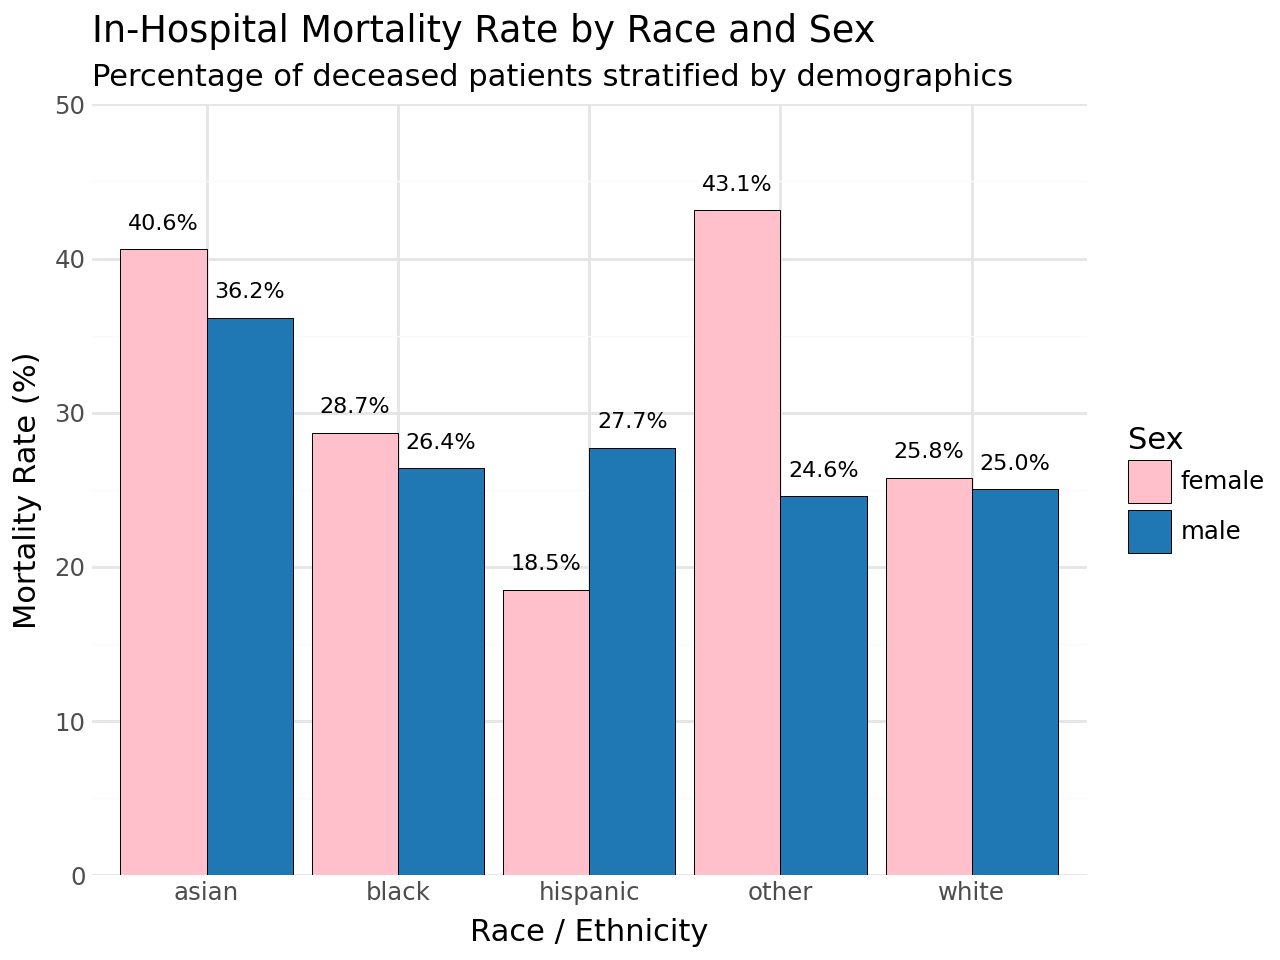

In [5]:
mortality_rates = df.groupby(['race', 'sex'])['hospdead'].mean().reset_index()
mortality_rates.rename(columns={'hospdead': 'mortality_rate'}, inplace=True)
mortality_rates['mortality_rate'] = mortality_rates['mortality_rate'] * 100

mortality_rates['label']    = mortality_rates['mortality_rate'].round(1).astype(str) + '%'
mortality_rates['label_y']  = mortality_rates['mortality_rate'] + 1.0   # the "nudge"


grafico_demografico = (
    p9.ggplot(mortality_rates, p9.aes(x='race', y='mortality_rate', fill='sex'))
    + p9.geom_col(position=p9.position_dodge(width=0.9),
                  color='black', size=0.2)
    + p9.geom_text(
        p9.aes(y='label_y', label='label'),           
        position=p9.position_dodge(width=0.9),        
        va='bottom',
        size=8,
    )
    + p9.scale_fill_manual(values={'male': '#1f77b4', 'female': 'pink'})
    + p9.theme_minimal()
    + p9.labs(
        title="In-Hospital Mortality Rate by Race and Sex",
        subtitle="Percentage of deceased patients stratified by demographics",
        x="Race / Ethnicity",
        y="Mortality Rate (%)",
        fill="Sex",
    )
    + p9.scale_y_continuous(limits=(0, 50), expand=(0, 0))
)
display(grafico_demografico)

This grouped bar chart illustrates the in-hospital mortality rates (%) of deceased patients across different racial/ethnic groups, separated by sex (female and male). The x-axis represents race/ethnicity categories (Asian, Black, Hispanic, Other, and White), while the y-axis shows mortality rates as percentages.

Key observations include:

* Asian patients show relatively high mortality rates for both sexes, with females at 40.6% and males at 36.2%.
* Black patients have moderate mortality rates, with females at 28.7% and males at 26.4%.
* Among Hispanic patients, males (27.7%) have noticeably higher mortality than females (18.5%).
* The Other racial category has the highest female mortality rate overall at 43.1%, while males are substantially lower at 24.6%.
* White patients show nearly equal mortality rates between females (25.8%) and males (25.0%).

A prevalent trend indicates that female patients experience a higher mortality rate compared to their male counterparts. 

**Request 4.** Using income, race, and age, produce an appropriate visualization that allows comparing the distribution of the age across both demographic dimensions simultaneously. Write a short paragraph discussing what the visualization reveals

/home/king/Desktop/ds/T14-dsv-exam-2026-1/.venv/lib/python3.12/site-packages/plotnine/stats/stat_density.py:179: PlotnineWarning: To compute the density of a group with only one value set the bandwidth manually. e.g `bw=0.1`
/home/king/Desktop/ds/T14-dsv-exam-2026-1/.venv/lib/python3.12/site-packages/plotnine/stats/stat_density.py:184: PlotnineWarning: Groups with fewer than 2 data points have been removed.


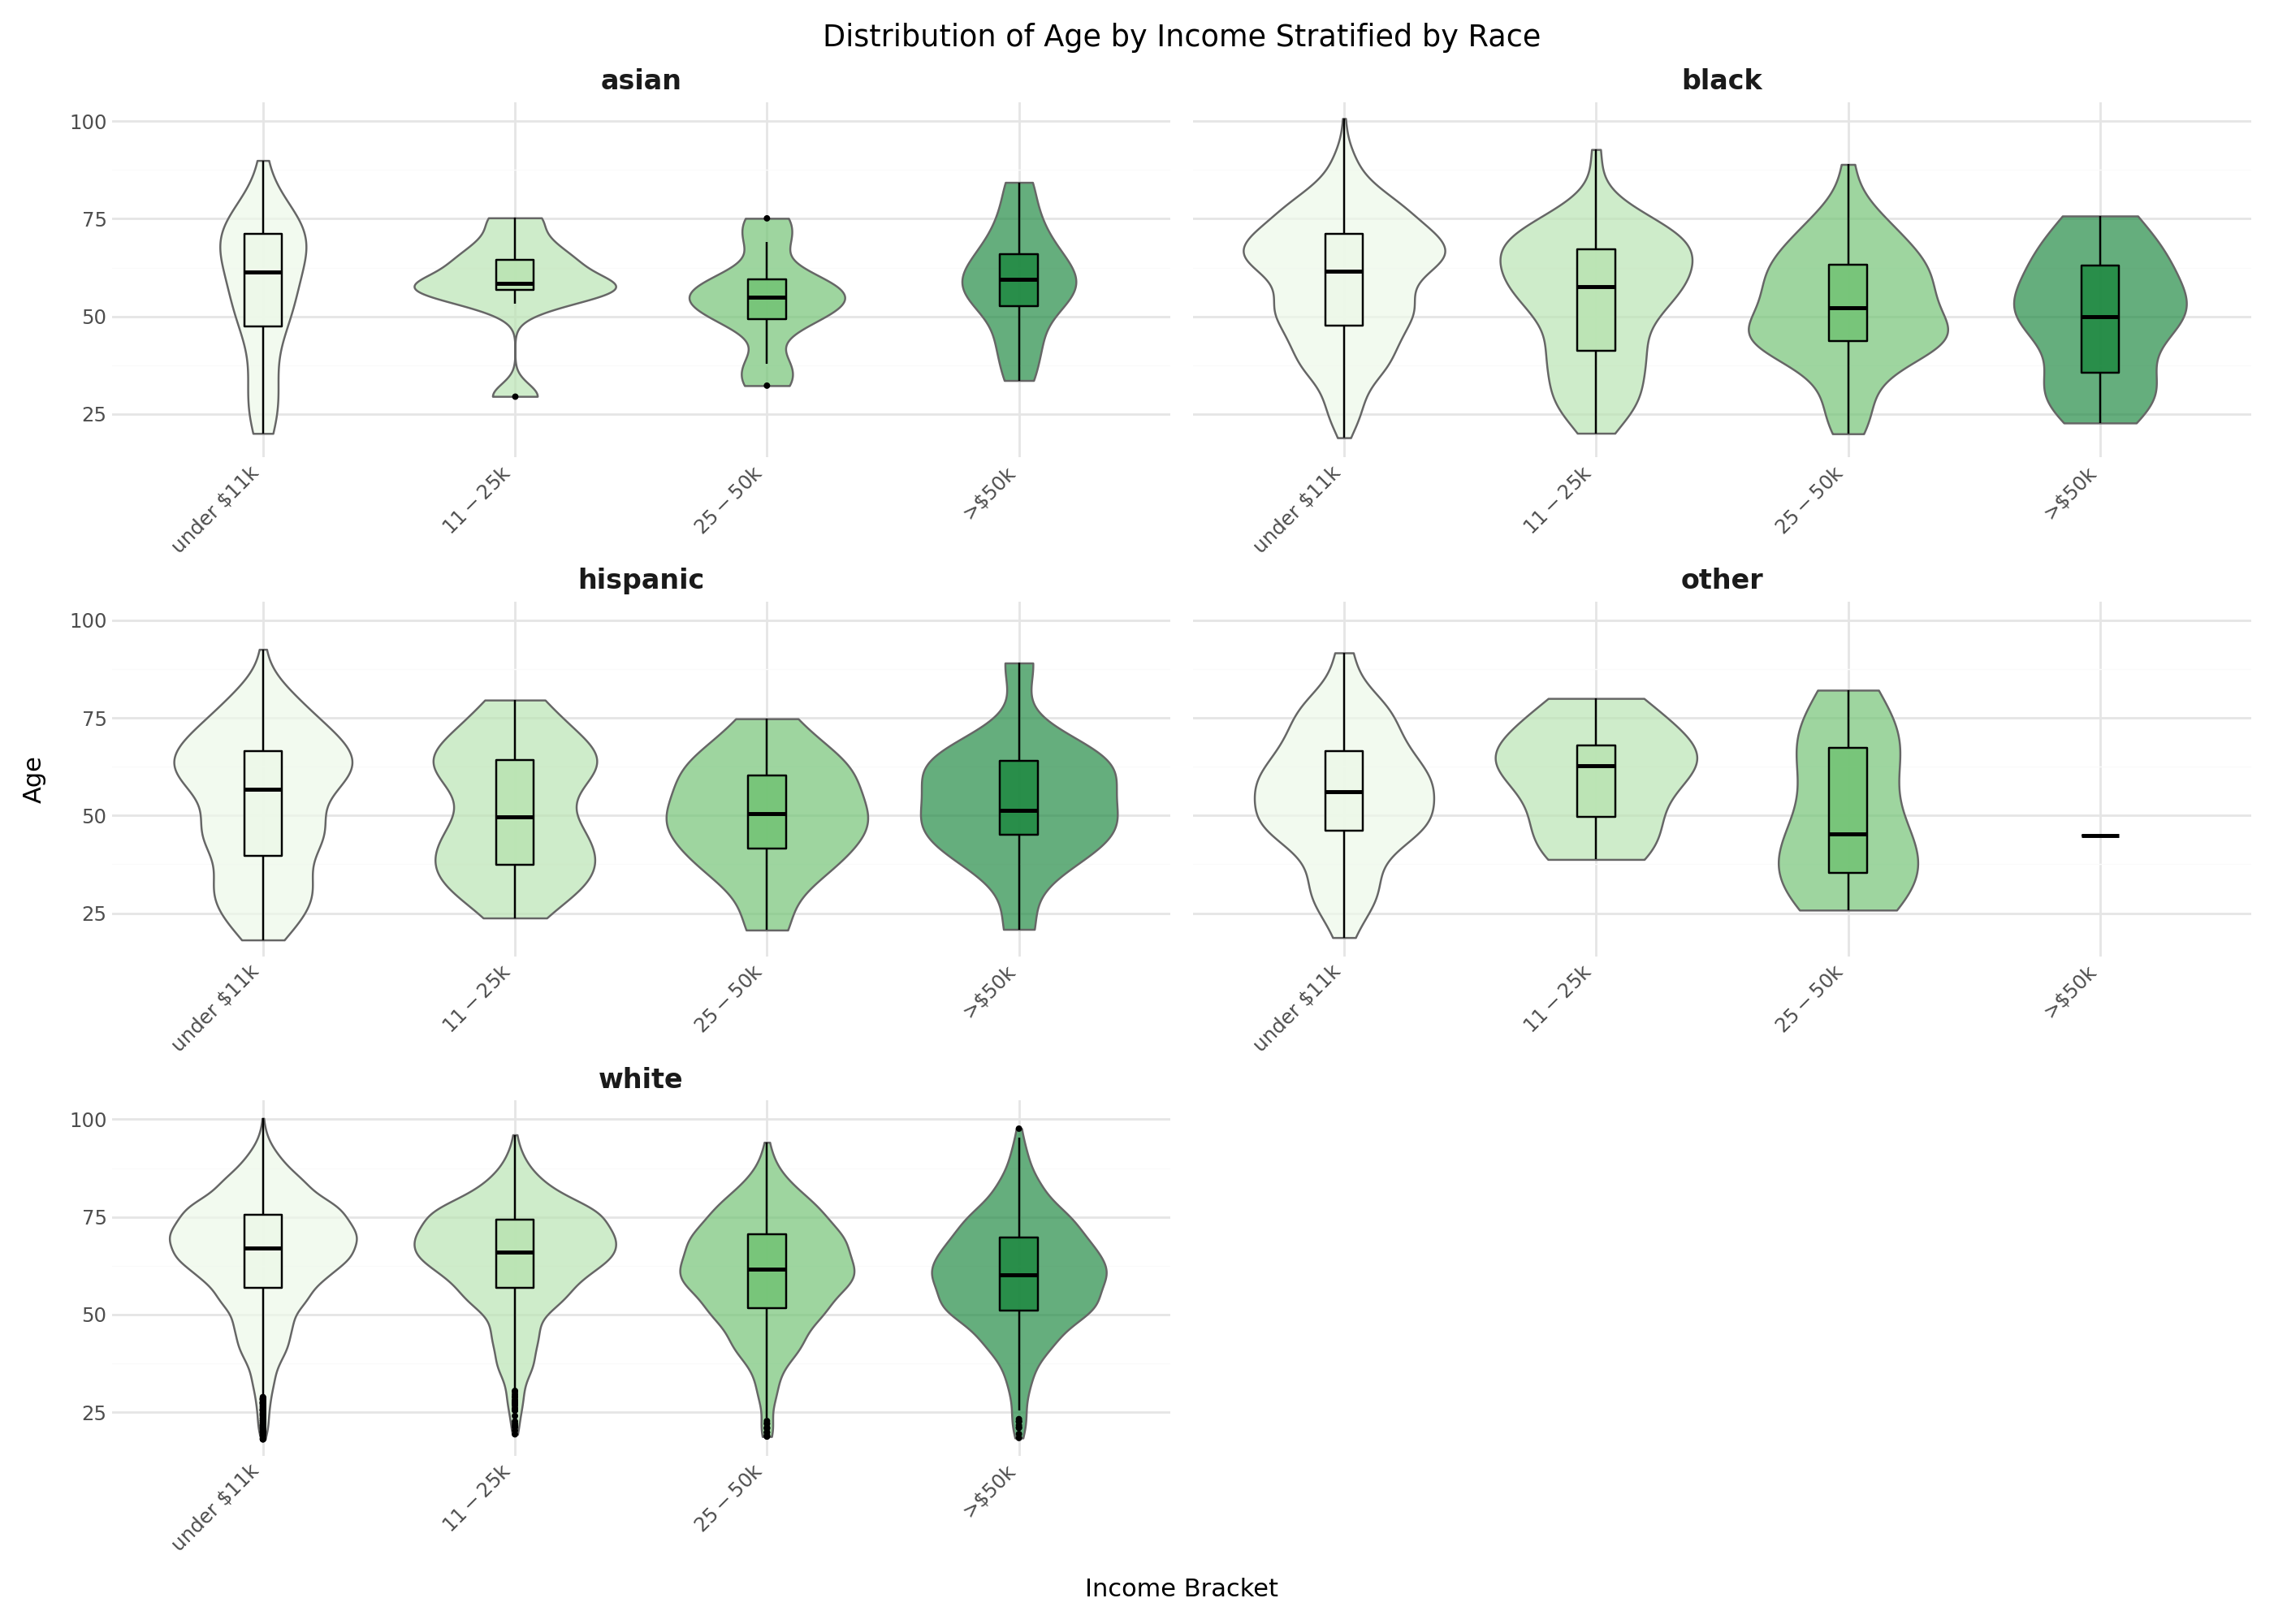

In [ ]:
income_order = df['income'].unique().tolist()

# I had a problem with the order because it wa showing "under 11k" after "11k-25k", I manually swapped for convinience
tmp = income_order[0]
income_order[0] = income_order[1]
income_order[1] = tmp
df['income'] = pd.Categorical(df['income'], categories=income_order, ordered=True)

dodge = p9.position_dodge(width=0.9)

(p9.ggplot(df, p9.aes(x='income', y='age', fill='income'))
 + p9.geom_violin(width=0.8, alpha=0.7, color='#666666')
 + p9.geom_boxplot(width=0.15, outlier_size=0.6, alpha=0.9, color='black')
 + p9.facet_wrap('~ race', ncol=2, scales='free_x') # <--- DIVIDES THE PLOT BY RACE
 + p9.scale_fill_brewer(type='seq', palette='Greens')
 + p9.labs(
     title="Distribution of Age by Income Stratified by Race",
     x='Income Bracket',
     y='Age'
   )
 + p9.theme_minimal()
 + p9.theme(
     figure_size=(14, 10),
     axis_text_x=p9.element_text(rotation=45, ha='right'),
     strip_text=p9.element_text(size=12, weight='bold'), 
     legend_position='none' 
   )
)


### Exploratory Data Analysis: Age and Income Stratified by Race

The visualization above utilizes a **faceted violin plot with overlaid box plots** to map the probability density and statistical distribution of patient **Age** across ordinal **Income** brackets, systematically stratified into distinct sub-panels by **Race**.

**Technical Structure & Methodology:**
* **Dual-Layer Visualization:** The outer "violin" layer displays the continuous kernel density estimation, intuitively showing where patient ages are most heavily concentrated. The inner box plot provides strict, standardized summary statistics, detailing the median (thick horizontal line), the interquartile range (the box), and the 95% confidence intervals (the whiskers).
* **Splitting the maps:** By splitting the visual space into individual panels based on race, this approach effectively isolates demographic subgroups. This is crucial in imbalanced datasets, as it prevents the heavily represented majority class (example: the `white` cohort) from visually masking or distorting the underlying distributions of minority classes.
* **Sequential Color Mapping:** The application of a sequential green palette smoothly reinforces the ordinal nature of the X-axis (from the lowest to the highest income bracket).

**Key Data Insights:**
1.  **General Age Concentration:** Across nearly all demographic intersections, the "bulge" of the violin plots highlights a heavy concentration of patients in the 50–80 year age range. This confirms the expected baseline demographics of a severe acute care 
2.  **Median Stability vs. Variance:** The white demographic exhibits high structural consistency; both the density shape and the median age remain highly stable across all four income brackets. In contrast, subgroups like hispanic and black exhibit more variance in their interquartile ranges and median ages as income fluctuates, likely due to the fact that we have more data for the white demographic than for all other races.
3.  **Identification of Data Sparsity:** This type of plot is excellent for exposing areas with insufficient sample sizes. Most notably, in the `other` race panel, the `>$50k` income bracket collapses into a single, flat horizontal line. This visually flags a severe lack of data points (in fact there is only a single observation) at that specific intersection, warning against drawing statistically significant conclusions for that specific micro-cohort.